# Data Mining Assingment 3 - Izaak King, kingi@rpi.edu
Attached is my submission for assignment 3.

## Charm Algorithm

First we implement the CHARM closed itemset mining algorith, as found in the textbook

In [3]:
#Inputs: P: list of tuples (itemset, tidset) with support > minsup, minsup: minimum support (integer), C: set of closed itemsets (empty)

def CHARM(P, minsup, C):
    P = sorted(P, key=lambda x: len(x[1]), reverse=True)  # Sort by support descending
    i = 0
    while i < len(P):
        Xi, tXi = P[i]
        Pi = []
        j = i + 1
        
        while j < len(P):
            Xj, tXj = P[j]
            Xij = tuple(sorted(set(Xi) | set(Xj)))     # Use | for set union, sort for output comparison later
            tXij = tXi & tXj                           # Use & for set intersection
            
            if len(tXij) >= minsup:
                
                if tXi == tXj:                
                    P[i] = (Xij, tXij)                  # Replace Xi with Xij in P
                    for index, (Xk, tXk) in enumerate(Pi):      # Use loop to find and replace Xi in Pi
                        if set(Xk) == set(Xi):          
                            Pi[index] = (Xij, tXij)             # Replace with combined Xij
                            break
                    P.pop(j)                           # Remove (Xj, tXj) from P
                    continue                           # Don't increment j, because list shifted
                    
                elif tXi.issubset(tXj):        
                    P[i] = (Xij, tXij)                            # Replace Xi with Xij in P
                    for index, (Xk, tXk) in enumerate(Pi):        # Use loop to find and replace Xi in Pi
                        if set(Xk) == set(Xi):  
                            Pi[index] = (Xij, tXij)                # Replace with combined Xij
                            break
                
                else:                             
                    Pi.append((Xij, tXij))
            j += 1
        
        
        if Pi:
            CHARM(Pi, minsup, C)
        
        doesNotExist = True            # doesNotExist variable will track if there exists a Z such that Xi subseteq Z and t(Xi) = t(Z)
        for Z, tZ in C:
            if set(Xi).issubset(set(Z)) and tXi == tZ:
                doesNotExist = False
                break
        if doesNotExist:             # Add Xi to closed set if no superset with same tidset exists
            C.append((Xi, tXi))
        
        i += 1

## Applying CHARM algorithm

Now, we use the implemented CHARM algorithm to find the frequent closed itemsets in the provided Reuters Newswire Data dataset, using minimum support of 50. We first parse the file into the desired CHARM input format, then we use our algorithm, printing out each valid itemset, with its corresponding support.

In [4]:
word_tidset = {}                           # First we read file and build word -> tidset mapping
with open("ModApte_words.txt", "r") as f:
    for tid, line in enumerate(f):  
        words = line.strip().split()
        for word in words:
            if word not in word_tidset:
                word_tidset[word] = set()  # Create set if word is new
            word_tidset[word].add(tid)     # Add current line number


minsup = 50
P = [( {word}, tids ) for word, tids in word_tidset.items() if len(tids) >= minsup]    # Build P with tuples that meet minsup
C = []

CHARM(P, minsup, C)             #Run CHARM algorithm

for itemset, tidset in C:
    items = ",".join(sorted(itemset))       # Join items with commas, sorted in lexographic
    print(f"{items} - {len(tidset)}")       # Format as: A,B,C - 3

print(f"Number of closed itemsets: {len(C)}")

last,would,year - 71
last,us,year - 68
1986,last,year - 67
billion,last,year - 63
last,year,years - 56
last,prices,year - 54
last,trade,year - 51
expected,last,year - 51
last,year - 149
us,would,year - 67
billion,would,year - 52
would,year - 116
us,year - 105
1986,year - 101
billion,year - 89
year,years - 81
new,year - 79
trade,year - 75
prices,year - 72
first,year - 69
expected,year - 68
government,year - 66
could,year - 64
1987,year - 59
may,year - 57
current,year - 57
added,year - 56
march,year - 56
week,year - 55
minister,year - 55
next,year - 54
foreign,year - 54
bank,year - 53
increase,year - 53
production,year - 53
three,year - 52
world,year - 51
market,year - 50
months,year - 50
domestic,year - 50
year - 254
trade,us,would - 71
last,us,would - 61
president,us,would - 57
japan,us,would - 54
economic,us,would - 52
could,us,would - 51
minister,us,would - 51
new,us,would - 50
us,would - 136
last,would - 102
trade,would - 91
new,would - 86
could,would - 82
billion,would - 76
preside

## CHARM Algorithm Analysis

After running our algorithm with minsup of 50, we will experiment with minsup from 50 down to 15 (in increments of 5). From these trials we can create two plots- the first being running time as a function of minimum support, and the second being number of closed frequent itemsets, also as a function of minimum support values.

minsup=50: runtime=0.047s, closed_itemsets=318
minsup=45: runtime=0.064s, closed_itemsets=432
minsup=40: runtime=0.113s, closed_itemsets=629
minsup=35: runtime=0.228s, closed_itemsets=965
minsup=30: runtime=0.432s, closed_itemsets=1616
minsup=25: runtime=1.294s, closed_itemsets=3045
minsup=20: runtime=5.654s, closed_itemsets=6714
minsup=15: runtime=50.772s, closed_itemsets=19148


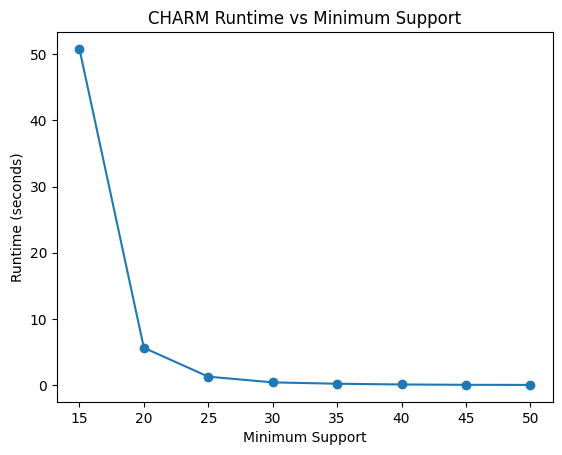

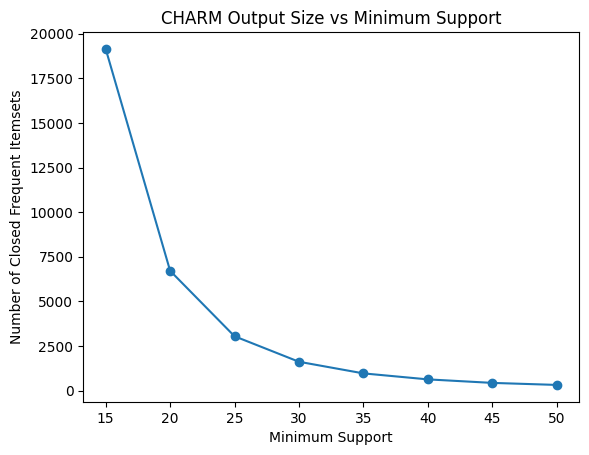

In [5]:
import time
import matplotlib.pyplot as plt


word_tidset = {}    # Read dataset once, building item -> tidset like before
with open("ModApte_words.txt", "r") as f:
    for tid, line in enumerate(f):
        words = line.strip().split()
        for word in words:
            if word not in word_tidset:
                word_tidset[word] = set()
            word_tidset[word].add(tid)


minsup_values = list(range(50, 10, -5))  # List of minsup values to test 50, 45, 40, ..., 15

runtimes = []
num_closed_itemsets = []

for minsup in minsup_values:          # Run through each minsup iteration

    P = [( {word}, tids ) for word, tids in word_tidset.items() if len(tids) >= minsup]    # Build initial P for each minsup
    C = []

    
    start_time = time.time()  # Measure runtime
    CHARM(P, minsup, C)
    end_time = time.time()

    runtimes.append(end_time - start_time)   # Append total runtime
    num_closed_itemsets.append(len(C))

    print(f"minsup={minsup}: runtime={end_time - start_time:.3f}s, closed_itemsets={len(C)}")  # Print outputs accordinly

# Plot runtime vs minsup
plt.plot(minsup_values, runtimes, marker='o')
plt.xlabel("Minimum Support")
plt.ylabel("Runtime (seconds)")
plt.title("CHARM Runtime vs Minimum Support")
plt.show()


# Plot number of closed frequent itemsets vs minsup
plt.plot(minsup_values, num_closed_itemsets, marker='o')
plt.xlabel("Minimum Support")
plt.ylabel("Number of Closed Frequent Itemsets")
plt.title("CHARM Output Size vs Minimum Support")

plt.show()
